# MobileNetV2 — Model Compression

Compress the trained MobileNetV2 pneumonia classifier using two techniques:
1. **Dynamic-range quantization** — weights compressed to INT8, no calibration needed
2. **Full INT8 quantization** — weights + activations to INT8, uses test samples for calibration

Compare size, accuracy, and inference speed before and after.

## 1. Imports & Setup

In [1]:
import os
import sys
import time
import tempfile
import numpy as np

os.environ["CUDA_VISIBLE_DEVICES"] = ""  # must be set before TF import

import tensorflow as tf

sys.path.append(os.path.abspath(".."))
from src.data.tf_dataset import get_generators

print("TensorFlow:", tf.__version__)

OUTPUT_DIR  = "../src/models"
DYNAMIC_OUT = os.path.join(OUTPUT_DIR, "mobilenetv2_dynamic.tflite")
INT8_OUT    = os.path.join(OUTPUT_DIR, "mobilenetv2_int8.tflite")

TensorFlow: 2.16.2


## 2. Load Model & Data

In [2]:
from src.models.transfer_learning import build_transfer_model

model = build_transfer_model(trainable_base=False)
model.load_weights("../src/models/pneumonia_mobilenetv2.keras")

# Warm-up pass — required before export() to initialise variables
_ = model(tf.zeros([1, 224, 224, 1]), training=False)

print("Model loaded OK")
model.summary()

train_gen, val_gen, test_gen = get_generators()

Model loaded OK


Model: "pneumonia_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ grayscale_to_rgb (Lambda)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,618,945 (9.99 MB)

 Trainable params: 360,961 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


## 3. Helper Functions

In [3]:
def file_mb(path):
    return os.path.getsize(path) / 1024 ** 2


def evaluate_keras(model, test_gen, max_batches=50):
    test_gen.reset()
    correct, total, times = 0, 0, []
    for i, (images, labels) in enumerate(test_gen):
        if i >= max_batches:
            break
        t0 = time.perf_counter()
        preds = model.predict(images, verbose=0).ravel()
        ms = (time.perf_counter() - t0) * 1000 / len(images)
        times.extend([ms] * len(images))
        correct += int(np.sum((preds >= 0.5) == labels))
        total += len(labels)
    return correct / total, np.mean(times)


def evaluate_tflite(tflite_path, test_gen, max_batches=50):
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()
    inp = interpreter.get_input_details()[0]
    out = interpreter.get_output_details()[0]

    test_gen.reset()
    correct, total, times = 0, 0, []
    for i, (images, labels) in enumerate(test_gen):
        if i >= max_batches:
            break
        for img, label in zip(images, labels):
            sample = img[np.newaxis].astype(inp["dtype"])
            t0 = time.perf_counter()
            interpreter.set_tensor(inp["index"], sample)
            interpreter.invoke()
            times.append((time.perf_counter() - t0) * 1000)
            pred = float(interpreter.get_tensor(out["index"])[0][0])
            correct += int((pred >= 0.5) == label)
            total += 1
    return correct / total, np.mean(times)

## 4. Dynamic-Range Quantization
Compresses weights from FP32 → INT8. No calibration data required. Fastest to apply.

In [4]:
# TF 2.16 on Apple Silicon has a bug where TFLiteConverter.from_keras_model()
# crashes on MobileNetV2 (MLIR "missing attribute 'value'" error).
# model.export() writes a SavedModel via a different path that avoids the bug.

_export_dir = tempfile.mkdtemp()
model.export(_export_dir)

converter = tf.lite.TFLiteConverter.from_saved_model(_export_dir)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open(DYNAMIC_OUT, "wb") as f:
    f.write(tflite_model)

print(f"Saved → {DYNAMIC_OUT}  ({file_mb(DYNAMIC_OUT):.1f} MB)")

INFO:tensorflow:Assets written to: /var/folders/h7/j_02l5tj1cs3h811s4hfr_xr0000gn/T/tmp4ako9cgc/assets


INFO:tensorflow:Assets written to: /var/folders/h7/j_02l5tj1cs3h811s4hfr_xr0000gn/T/tmp4ako9cgc/assets


Saved artifact at '/var/folders/h7/j_02l5tj1cs3h811s4hfr_xr0000gn/T/tmp4ako9cgc'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 1), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5404338736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5404337680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5404335920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5404335216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5404336624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5404332048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5404591904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5404594192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5404590672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5404592256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5404598416: TensorSpec(shap

W0000 00:00:1776014501.779656 4991784 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1776014501.779673 4991784 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2026-04-12 22:51:41.780205: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/h7/j_02l5tj1cs3h811s4hfr_xr0000gn/T/tmp4ako9cgc
2026-04-12 22:51:41.785248: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-12 22:51:41.785257: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/h7/j_02l5tj1cs3h811s4hfr_xr0000gn/T/tmp4ako9cgc
2026-04-12 22:51:41.866584: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2026-04-12 22:51:41.876390: I tensorflow/cc/saved_model/loader.cc:234] Restoring SavedModel bundle.
2026-04-12 22:51:42.186703: I tensorflow/cc/saved_model/loader.cc:218] Running initialization op on SavedModel bundle at 

## 5. Full INT8 Quantization
Quantizes both weights and activations to INT8. Needs a small representative dataset to calibrate activation ranges.

In [5]:
# Collect 100 test samples for calibration
test_gen.reset()
samples = []
for images, _ in test_gen:
    samples.append(images)
    if sum(x.shape[0] for x in samples) >= 100:
        break
calib_data = np.concatenate(samples)[:100].astype(np.float32)

def rep_dataset():
    for img in calib_data:
        yield [img[np.newaxis]]

_export_dir2 = tempfile.mkdtemp()
model.export(_export_dir2)

converter = tf.lite.TFLiteConverter.from_saved_model(_export_dir2)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = rep_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32
tflite_model = converter.convert()

with open(INT8_OUT, "wb") as f:
    f.write(tflite_model)

print(f"Saved → {INT8_OUT}  ({file_mb(INT8_OUT):.1f} MB)")

INFO:tensorflow:Assets written to: /var/folders/h7/j_02l5tj1cs3h811s4hfr_xr0000gn/T/tmp981avet0/assets


INFO:tensorflow:Assets written to: /var/folders/h7/j_02l5tj1cs3h811s4hfr_xr0000gn/T/tmp981avet0/assets


Saved artifact at '/var/folders/h7/j_02l5tj1cs3h811s4hfr_xr0000gn/T/tmp981avet0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 1), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5404338736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5404337680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5404335920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5404335216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5404336624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5404332048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5404591904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5404594192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5404590672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5404592256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5404598416: TensorSpec(shap

W0000 00:00:1776014516.063130 4991784 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1776014516.063144 4991784 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2026-04-12 22:51:56.063306: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/h7/j_02l5tj1cs3h811s4hfr_xr0000gn/T/tmp981avet0
2026-04-12 22:51:56.068033: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-12 22:51:56.068042: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/h7/j_02l5tj1cs3h811s4hfr_xr0000gn/T/tmp981avet0
2026-04-12 22:51:56.150135: I tensorflow/cc/saved_model/loader.cc:234] Restoring SavedModel bundle.
2026-04-12 22:51:56.449574: I tensorflow/cc/saved_model/loader.cc:218] Running initialization op on SavedModel bundle at path: /var/folders/h7/j_02l5tj1cs3h811s4hfr_xr0000gn/T/tmp981avet0
2026-04-12 22:51:56.529458: I tensorflow/cc/saved_model/loader.cc:

Saved → ../src/models/mobilenetv2_int8.tflite  (2.9 MB)


fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32


## 6. Compare: Size, Accuracy & Inference Speed

In [6]:
print("Evaluating models (50 batches each) …\n")

base_acc,    base_ms    = evaluate_keras(model, test_gen)
dynamic_acc, dynamic_ms = evaluate_tflite(DYNAMIC_OUT, test_gen)
int8_acc,    int8_ms    = evaluate_tflite(INT8_OUT,    test_gen)

# Get baseline file size by saving temporarily
tmp = os.path.join(OUTPUT_DIR, "_tmp.keras")
model.save(tmp)
baseline_mb = file_mb(tmp)
os.remove(tmp)

results = [
    ("Baseline  (FP32 Keras)",   baseline_mb,          base_acc,    base_ms),
    ("Dynamic-range quant",      file_mb(DYNAMIC_OUT), dynamic_acc, dynamic_ms),
    ("Full INT8 quant",          file_mb(INT8_OUT),    int8_acc,    int8_ms),
]

print(f"{'Model':<28} {'Size':>7} {'Reduction':>10} {'Accuracy':>10} {'ms/img':>8}")
print("─" * 68)
for name, mb, acc, ms in results:
    reduction = (1 - mb / baseline_mb) * 100
    print(f"{name:<28} {mb:>6.1f} MB {reduction:>9.1f}% {acc*100:>9.2f}% {ms:>7.2f} ms")

Evaluating models (50 batches each) …



INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Model                           Size  Reduction   Accuracy   ms/img
────────────────────────────────────────────────────────────────────
Baseline  (FP32 Keras)         10.6 MB       0.0%     84.69%    6.56 ms
Dynamic-range quant             2.7 MB      74.1%     88.71%    6.11 ms
Full INT8 quant                 2.9 MB      72.3%     84.95%    3.78 ms


## 7. Visualize Results

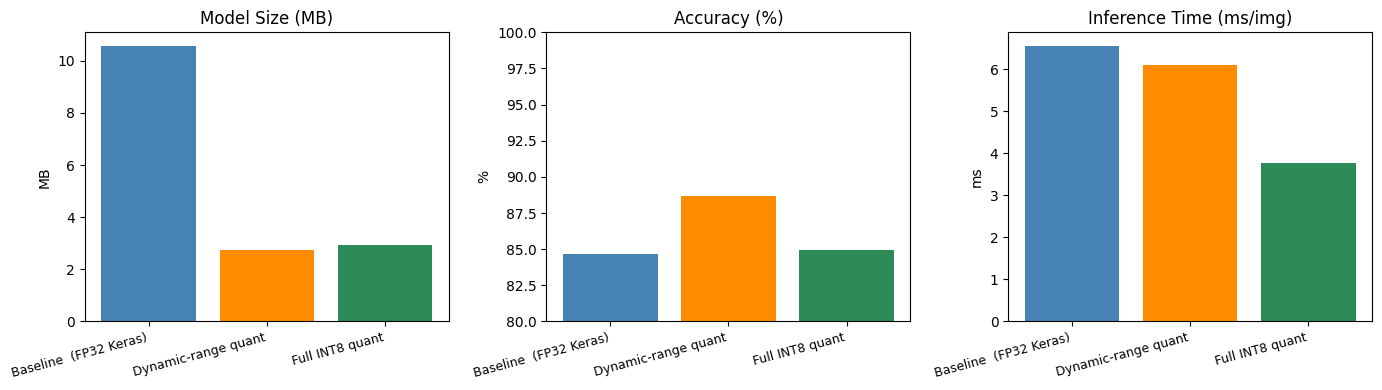

In [7]:
import matplotlib.pyplot as plt

labels   = [r[0] for r in results]
sizes    = [r[1] for r in results]
accs     = [r[2] * 100 for r in results]
ms_times = [r[3] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ["steelblue", "darkorange", "seagreen"]

axes[0].bar(labels, sizes, color=colors)
axes[0].set_title("Model Size (MB)")
axes[0].set_ylabel("MB")

axes[1].bar(labels, accs, color=colors)
axes[1].set_title("Accuracy (%)")
axes[1].set_ylim(80, 100)
axes[1].set_ylabel("%")

axes[2].bar(labels, ms_times, color=colors)
axes[2].set_title("Inference Time (ms/img)")
axes[2].set_ylabel("ms")

for ax in axes:
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=9)

plt.tight_layout()
plt.savefig("../results/plots/compression_comparison.png", dpi=150)
plt.show()